In [1]:
from tqdm import tqdm
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th

import gymnasium as gym
import sys
import os

# sys.path.append(os.path.abspath(".."))
sys.path.insert(0, os.path.abspath(".."))
import importlib
if "gym_anytrading" in sys.modules:
    del sys.modules["gym_anytrading"]      # remove cached version
    del sys.modules["gym_anytrading.envs"] # remove submodule cache too

import gym_anytrading   

from stable_baselines3 import PPO,DQN
from stable_baselines3.common.callbacks import BaseCallback

In [2]:
# !pip install stable-baselines3[extra]

In [3]:
# Create Env
env_name = "stocks-v0"
env = gym.make(env_name)

In [4]:
def print_stats(reward_over_episodes):
    avg = np.mean(reward_over_episodes)
    min = np.min(reward_over_episodes)
    max = np.max(reward_over_episodes)

    print(f"Average Reward: {avg}")
    print(f"Minimum Reward: {min}")
    print(f"Maximum Reward: {max}")

    return min,avg,max

In [5]:
class ProgressBarCallback(BaseCallback):
    def __init__(self,check_freq: int,verbose: int=1):
        super().__init__(verbose)
        self.check_freq = check_freq
    
    """calling this method before the first rollout starts (i.e. before the first call to the `env.step()` method)"""
    def _on_training_start(self) -> None:
        self.progress_bar = tqdm(total = self.model._total_timesteps, desc = "model.learn()")
    
    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:
            self.progress_bar.update(self.check_freq)

        return True
    
    def _on_training_end(self) -> None:
        self.progress_bar.close()
    

In [6]:
# training+test
def train_test_model(model,env,seed,total_num_episodes,total_learning_timesteps=10_000):

    print("-"*80)
    # Every run starts with same initial state
    obs = env.reset(seed=seed)
    # same Weight initialization
    th.manual_seed(seed)
    # Controls python's built-in randomness 
    random.seed(seed)
    # Controls numpy randomness (Sampling)
    np.random.seed(seed)

    vec_env = None

    if model is not None:
        print(f'Model {type(model)}')
        print(f"Policy: {type(model.policy)}")
        
        model.learn(total_timesteps=total_learning_timesteps,callback=ProgressBarCallback(check_freq=100))

        vec_env = model.get_env()
        obs = vec_env.reset()
    else:
        print("Random Actions")
    
    reward_over_episodes = []

    tbar = tqdm(range(total_num_episodes))

    for episode in tbar:

        if vec_env:
            obs = vec_env.reset()
        else:
            obs, info = env.reset()
        
        total_reward = 0
        done = False

        while not done:
            if model is not None:
                action, _ = model.predict(obs)
                try:
                    obs, reward, done, info = vec_env.step(action)
                except IndexError:
                    obs = vec_env.reset()
                    reward, done = 0.0, True
            else:
                action = env.action_space.sample()
                try:
                    obs, reward, terminated, truncated, info = env.step(action)
                    done = terminated or truncated
                except IndexError:
                    obs, _ = env.reset()
                    reward, done = 0.0, True
            total_reward += reward
            if done:
                break

        reward_over_episodes.append(total_reward)

        if episode % 10 == 0:
            avg_reward= np.mean(reward_over_episodes)
            tbar.set_description(f'Episode: {episode}, Avg. Reward: {avg_reward:.3f}')
            tbar.update()
    
    tbar.close()
    avg_reward = np.mean(reward_over_episodes)

    return reward_over_episodes

In [7]:
seed = 42
total_num_episodes = 100

print("env_name:", env_name)
print("seed:",seed)

plot_settings = {}
plot_data = {'x': [i for i in range(1,total_num_episodes+1)]}

model = None
total_learning_timesteps = 0
rewards = train_test_model(model,env,seed,total_num_episodes, total_learning_timesteps)
min, avg, max = print_stats(rewards)

class_name = f"Random actions"
label = f"Avg. {avg:>7.2f} : {class_name}"
plot_data['rnd_rewards'] = rewards
plot_settings['rnd_rewards'] = {'label': label}

learning_timesteps_list_in_K = [25]

model_class_list = [PPO, DQN]

for timesteps in learning_timesteps_list_in_K:
    total_learning_timesteps = timesteps * 1000
    step_key = f'{timesteps}K'
    
    for model_class in model_class_list:
        policy_dict = model_class.policy_aliases
        
        policy = policy_dict.get('MlpPolicy')
        if policy is None:
            policy = policy_dict.get('MlpLstmPolicy')
        
        try:
            model = model_class(policy, env, verbose=0)
            class_name = type(model).__qualname__
            plot_key = f'{class_name}_rewards_'+step_key
            rewards = train_test_model(model, env, seed, total_num_episodes, total_learning_timesteps)
            min, avg, max, = print_stats(rewards)
            label = f'Avg. {avg:>7.2f} : {class_name} - {step_key}'
            plot_data[plot_key] = rewards
            plot_settings[plot_key] = {'label': label}     
                   
        except Exception as e:
            print(f"ERROR: {str(e)}")
            continue



env_name: stocks-v0
seed: 42
--------------------------------------------------------------------------------
Random Actions


Episode: 90, Avg. Reward: 277.448: 100%|██████████| 100/100 [00:06<00:00, 14.45it/s]


Average Reward: 274.585205078125
Minimum Reward: -131.28041076660156
Maximum Reward: 778.26708984375
--------------------------------------------------------------------------------
Model <class 'stable_baselines3.ppo.ppo.PPO'>
Policy: <class 'stable_baselines3.common.policies.ActorCriticPolicy'>


model.learn(): 26600it [03:25, 129.68it/s]                           
Episode: 90, Avg. Reward: 609.445: 100%|██████████| 100/100 [08:33<00:00,  5.13s/it]


Average Reward: 608.1989135742188
Minimum Reward: -30.121124267578125
Maximum Reward: 1216.0738525390625
--------------------------------------------------------------------------------
Model <class 'stable_baselines3.dqn.dqn.DQN'>
Policy: <class 'stable_baselines3.dqn.policies.DQNPolicy'>


Episode: 90, Avg. Reward: 958.094: 100%|██████████| 100/100 [01:23<00:00,  1.19it/s]

Average Reward: 959.4247436523438
Minimum Reward: 735.497314453125
Maximum Reward: 1142.699951171875


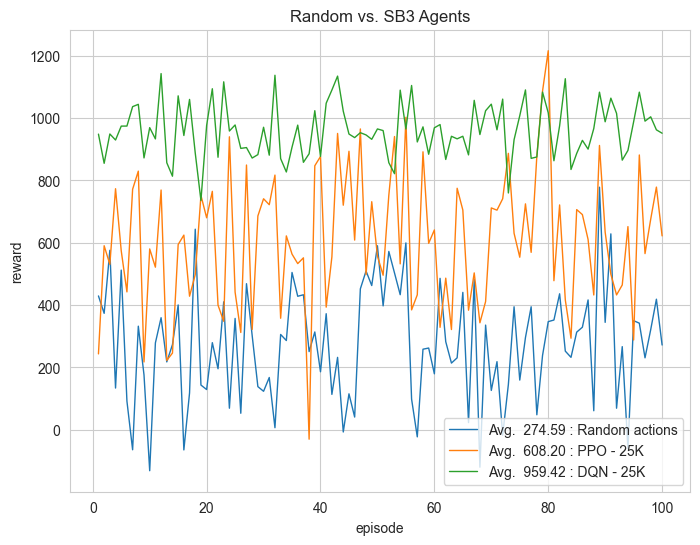

In [8]:
data = pd.DataFrame(plot_data)

sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))

for key in plot_data:
    if key == 'x':
        continue
    label = plot_settings[key]['label']
    line = plt.plot('x', key, data=data, linewidth=1, label=label)

plt.xlabel('episode')
plt.ylabel('reward')
plt.title('Random vs. SB3 Agents')
plt.legend()
plt.show()